# LEAFGUARD AI — Research Experiment Notebook
### Lightweight Multi-Class Crop Leaf Disease Identification with CBAM + MobileNetV3-Small and Grad-CAM

**Purpose:** A Google Colab-ready, end-to-end research notebook that downloads the Kaggle dataset, trains a MobileNetV3-Small baseline and a CBAM-enhanced model, evaluates classification and efficiency metrics, generates publication-ready plots/diagrams, produces Grad-CAM explanations, and exports a complete results package for the IEEE paper/report.

**Project specification used:** CBAM attention + lightweight MobileNet architecture + Grad-CAM explainability + comparison of accuracy, Macro-F1, parameters, FLOPs, model size and CPU/GPU inference speed.

> **Important research note:** The notebook does **not** assume that CBAM improves accuracy by 5–8%. That figure is treated as the project hypothesis/target. The final paper should report the measured result, including cases where the hypothesis is not supported.


In [18]:
# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================
!pip -q install kagglehub grad-cam torchinfo thop fvcore seaborn scikit-learn pandas matplotlib pillow tqdm

print("Libraries installed.")


Libraries installed.


## 2. Imports and Reproducibility

This section fixes random seeds and creates a standard directory structure. A CUDA GPU is strongly recommended for training.


In [19]:
import os, sys, json, time, random, shutil, math, copy, zipfile, subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Small_Weights

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

from thop import profile
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Training will be very slow.")

ROOT = Path.cwd()
DATA_ROOT = ROOT / "data"
RUN_ROOT = ROOT / "runs"
FIG_ROOT = RUN_ROOT / "figures"
MODEL_ROOT = RUN_ROOT / "models"
REPORT_ROOT = RUN_ROOT / "reports"

for p in [DATA_ROOT, RUN_ROOT, FIG_ROOT, MODEL_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Output directory:", RUN_ROOT)


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Output directory: /home/gopal/Downloads/capstone/runs


## 3. Experiment Configuration

### Recommended paper experiment
- 38 classes
- 224×224 input
- Cross-Entropy loss
- AdamW
- learning rate = 3e-4
- weight decay = 1e-4
- cosine learning-rate schedule
- batch size = 32
- 20 epochs with early stopping

For a quick smoke test, set `QUICK_RUN = True`. **Do not use QUICK_RUN results as final paper results.**


In [20]:
# ========================= USER CONFIG =========================
QUICK_RUN = False          # True = fast debugging only; False = research run
EPOCHS = 20
BATCH_SIZE = 32
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_WORKERS = 0
IMAGE_SIZE = 224

# To reduce training time for an initial run, set a positive integer.
# Leave None for the complete dataset.
MAX_TRAIN_PER_CLASS = None
MAX_VAL_PER_CLASS = None
MAX_TEST_PER_CLASS = None

# Dataset source
KAGGLE_DATASET = "vipoooool/new-plant-diseases-dataset"

# Experiment split from the labeled training data:
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

if QUICK_RUN:
    EPOCHS = 2
    PATIENCE = 1
    MAX_TRAIN_PER_CLASS = 80
    MAX_VAL_PER_CLASS = 20
    MAX_TEST_PER_CLASS = 20

print("Configuration loaded.")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")


Configuration loaded.
Epochs: 20 | Batch: 32 | LR: 0.0003


## 4. Download the Kaggle Dataset

The cell first tries KaggleHub. If authentication is required, it asks for the Kaggle username and API key and creates the temporary `kaggle.json` credential file.

**Do not paste your API key into the notebook source or into the paper.**


In [21]:
# ============================================================
# 4. KAGGLE DOWNLOAD
# ============================================================
import getpass

def find_dataset_root(base):
    base = Path(base)
    candidates = [base] + [p for p in base.rglob("*") if p.is_dir()]
    for p in candidates:
        names = {x.name.lower() for x in p.iterdir()} if p.exists() else set()
        if "train" in names or "valid" in names or "validation" in names:
            return p
    return base

dataset_path = None

try:
    import kagglehub
    print("Attempting KaggleHub download...")
    dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print("Downloaded to:", dataset_path)
except Exception as e:
    print("KaggleHub automatic download failed:", str(e)[:500])
    print("\nTrying Kaggle API authentication...")

    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / "kaggle.json"

    username = input("Kaggle username: ").strip()
    api_key = getpass.getpass("Kaggle API key (input is hidden): ").strip()

    with open(kaggle_json, "w") as f:
        json.dump({"username": username, "key": api_key}, f)
    os.chmod(kaggle_json, 0o600)

    try:
        import kaggle
        dataset_path = Path(kaggle.api.dataset_download_files(
            KAGGLE_DATASET,
            path=str(DATA_ROOT),
            unzip=True
        ) or DATA_ROOT)
    except Exception:
        subprocess.run([
            sys.executable, "-m", "pip", "install", "-q", "kaggle"
        ], check=True)
        subprocess.run([
            "kaggle", "datasets", "download",
            "-d", KAGGLE_DATASET,
            "-p", str(DATA_ROOT),
            "--unzip"
        ], check=True)
        dataset_path = DATA_ROOT

DATASET_ROOT = find_dataset_root(dataset_path)
print("Dataset root detected:", DATASET_ROOT)

# Show immediate directory structure
for p in list(DATASET_ROOT.iterdir())[:30]:
    print(" -", p.name)


Attempting KaggleHub download...
Downloaded to: /home/gopal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2
Dataset root detected: /home/gopal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
 - train
 - valid


## 5. Locate the Labeled Image Folders

The New Plant Diseases Dataset commonly contains `train` and `valid` directories. For a controlled paper experiment, this notebook builds a **stratified train/validation/test split from the labeled training data** so that the final test set remains untouched during training and early stopping.

If a different directory layout is detected, the notebook searches recursively for a folder containing class subdirectories.


In [22]:
def locate_split(root, preferred=("train", "training")):
    root = Path(root)
    for name in preferred:
        direct = root / name
        if direct.is_dir():
            class_dirs = [p for p in direct.iterdir() if p.is_dir()]
            if len(class_dirs) >= 2:
                return direct
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in preferred:
            class_dirs = [x for x in p.iterdir() if x.is_dir()]
            if len(class_dirs) >= 2:
                return p
    raise FileNotFoundError("Could not locate a labeled training directory.")

SOURCE_TRAIN = locate_split(DATASET_ROOT)
print("Labeled source directory:", SOURCE_TRAIN)

class_names = sorted([p.name for p in SOURCE_TRAIN.iterdir() if p.is_dir()])
print("Number of classes:", len(class_names))
print("First classes:", class_names[:10])

if len(class_names) != 38:
    print("WARNING: Expected 38 classes for the stated project specification.")


Labeled source directory: /home/gopal/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Number of classes: 38
First classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


## 6. Dataset Distribution and Sample Visualization

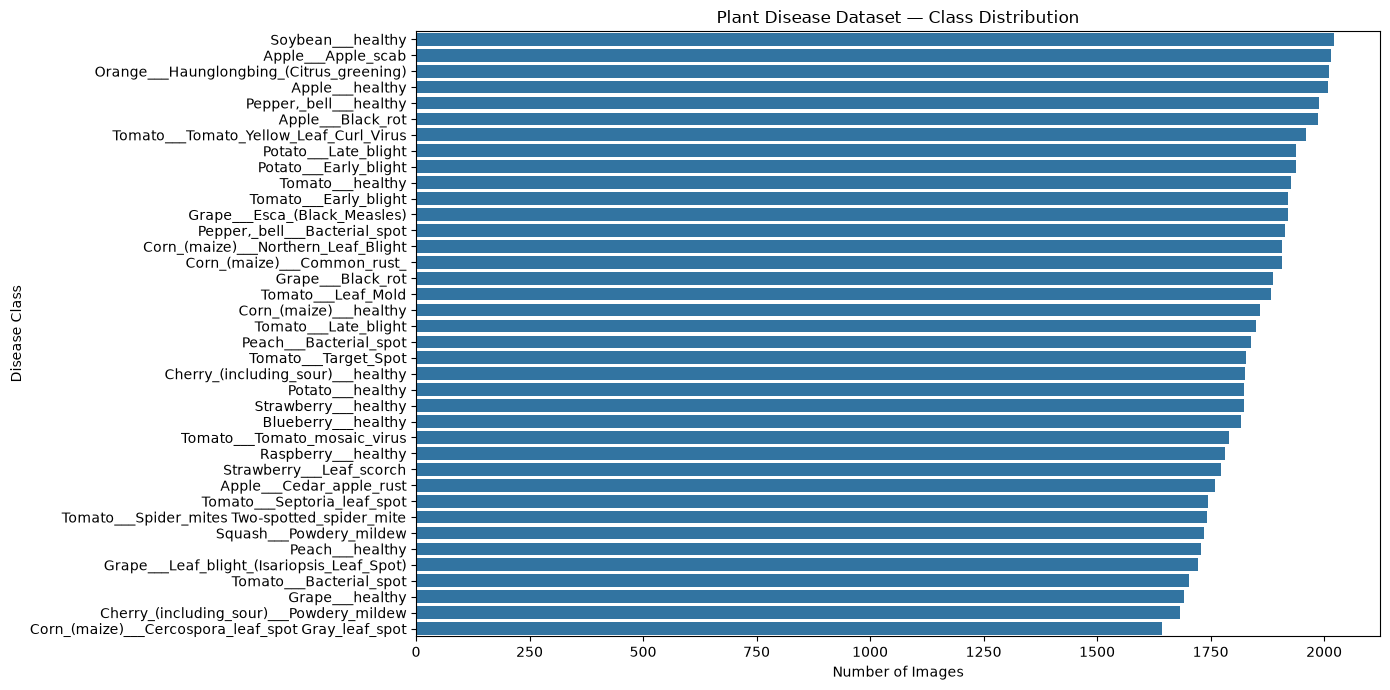

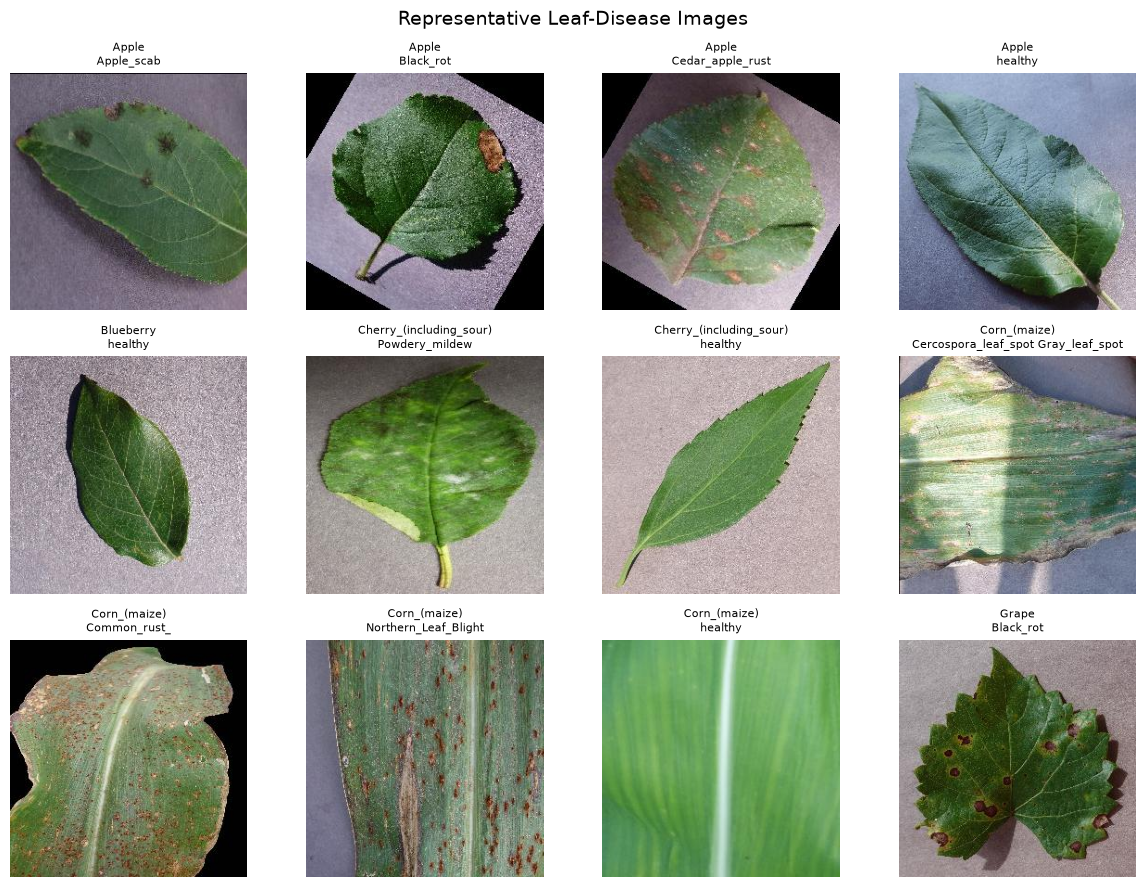

In [23]:
# Count images per class
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_counts = {}
for cls in class_names:
    class_counts[cls] = sum(
        1 for p in (SOURCE_TRAIN / cls).rglob("*")
        if p.suffix.lower() in IMG_EXTS
    )

dist_df = pd.DataFrame({"class": list(class_counts), "images": list(class_counts.values())})
dist_df = dist_df.sort_values("images", ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=dist_df, x="images", y="class")
plt.title("Plant Disease Dataset — Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")
plt.tight_layout()
plt.savefig(FIG_ROOT / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Show one sample per a few classes
sample_classes = class_names[:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, cls in zip(axes.ravel(), sample_classes):
    files = [p for p in (SOURCE_TRAIN / cls).rglob("*") if p.suffix.lower() in IMG_EXTS]
    if files:
        img = Image.open(files[0]).convert("RGB")
        ax.imshow(img)
    ax.set_title(cls.replace("___", "\n"), fontsize=8)
    ax.axis("off")
plt.suptitle("Representative Leaf-Disease Images", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_ROOT / "02_sample_images.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Build a Stratified Train / Validation / Test Split

The split is performed at the **image level within each disease class**. The test set is not used for model selection.

For a final paper, save the generated split manifest so the experiment can be reproduced exactly.


In [24]:
# Build file/class dataframe
records = []
for label, cls in enumerate(class_names):
    for p in (SOURCE_TRAIN / cls).rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            records.append({"path": str(p), "label": label, "class": cls})

all_df = pd.DataFrame(records)

def cap_per_class(df, max_per_class):
    if max_per_class is None:
        return df
    return (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(min(len(x), max_per_class), random_state=SEED))
          .reset_index(drop=True)
    )

all_df = cap_per_class(all_df, MAX_TRAIN_PER_CLASS)

train_df, temp_df = train_test_split(
    all_df,
    test_size=(1 - TRAIN_RATIO),
    stratify=all_df["label"],
    random_state=SEED
)

val_fraction_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1 - val_fraction_of_temp),
    stratify=temp_df["label"],
    random_state=SEED
)

if MAX_VAL_PER_CLASS:
    val_df = cap_per_class(val_df, MAX_VAL_PER_CLASS)
if MAX_TEST_PER_CLASS:
    test_df = cap_per_class(test_df, MAX_TEST_PER_CLASS)

split_dir = RUN_ROOT / "splits"
split_dir.mkdir(exist_ok=True)
train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")


Train: 56,236
Val:   7,029
Test:  7,030


## 8. Data Pipeline

Both models use the same input resolution and normalization. The **primary comparison** follows the project brief by comparing the CBAM model against a standard MobileNetV3-Small baseline.

A separate augmentation ablation can be added later if the paper needs to isolate augmentation from attention.


In [25]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class LeafData(torch.utils.data.Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["label"])

train_ds = LeafData(train_df, train_tf)
val_ds = LeafData(val_df, eval_tf)
test_ds = LeafData(test_df, eval_tf)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

print("Dataloaders ready.")


Dataloaders ready.


## 9. MobileNetV3-Small + CBAM Architecture

CBAM combines:
1. **Channel attention** — learns which feature channels are important.
2. **Spatial attention** — learns which spatial locations are important.

The implementation inserts a CBAM block after each MobileNetV3-Small inverted-residual feature block, matching the project documentation.


In [26]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * attn


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(7)

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x


def build_baseline(num_classes=38):
    weights = MobileNet_V3_Small_Weights.DEFAULT
    model = models.mobilenet_v3_small(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_cbam(num_classes=38):
    weights = MobileNet_V3_Small_Weights.DEFAULT
    model = models.mobilenet_v3_small(weights=weights)

    # Insert CBAM after every InvertedResidual feature block.
    new_features = []
    for block in model.features:
        new_features.append(block)
        if isinstance(block, models.mobilenetv3.InvertedResidual):
            # Infer output channels from block output by inspecting final conv.
            out_channels = block.out_channels
            new_features.append(CBAM(out_channels))

    model.features = nn.Sequential(*new_features)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


baseline = build_baseline(len(class_names)).to(DEVICE)
cbam_model = build_cbam(len(class_names)).to(DEVICE)

print("Baseline parameters:", sum(p.numel() for p in baseline.parameters()))
print("CBAM parameters:", sum(p.numel() for p in cbam_model.parameters()))


Baseline parameters: 1556806
CBAM parameters: 1562524


## 10. Architecture / Research Workflow Diagram

This diagram is generated automatically and can be inserted into the paper/report.


## 10A. CBAM Internal Architecture Diagram

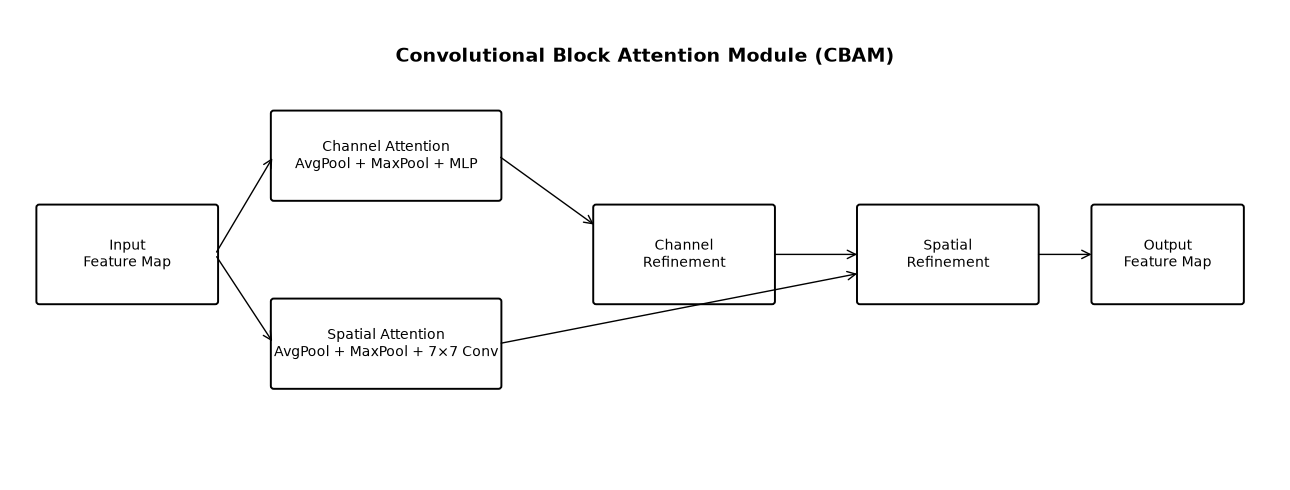

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def cbam_diagram(path):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 5)
    ax.axis("off")

    def box(x, y, w, h, text):
        r = FancyBboxPatch((x,y), w,h, boxstyle="round,pad=0.03",
                           linewidth=1.4, fill=False)
        ax.add_patch(r)
        ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=10)

    box(0.3, 1.9, 1.8, 1.0, "Input\nFeature Map")
    box(2.7, 3.0, 2.3, 0.9, "Channel Attention\nAvgPool + MaxPool + MLP")
    box(2.7, 1.0, 2.3, 0.9, "Spatial Attention\nAvgPool + MaxPool + 7×7 Conv")
    box(6.0, 1.9, 1.8, 1.0, "Channel\nRefinement")
    box(8.7, 1.9, 1.8, 1.0, "Spatial\nRefinement")
    box(11.1, 1.9, 1.5, 1.0, "Output\nFeature Map")

    ax.add_patch(FancyArrowPatch((2.1,2.4),(2.7,3.45),arrowstyle="->",mutation_scale=15))
    ax.add_patch(FancyArrowPatch((2.1,2.4),(2.7,1.45),arrowstyle="->",mutation_scale=15))
    ax.add_patch(FancyArrowPatch((5.0,3.45),(6.0,2.7),arrowstyle="->",mutation_scale=15))
    ax.add_patch(FancyArrowPatch((5.0,1.45),(8.7,2.2),arrowstyle="->",mutation_scale=15))
    ax.add_patch(FancyArrowPatch((7.8,2.4),(8.7,2.4),arrowstyle="->",mutation_scale=15))
    ax.add_patch(FancyArrowPatch((10.5,2.4),(11.1,2.4),arrowstyle="->",mutation_scale=15))

    ax.text(6.5, 4.45, "Convolutional Block Attention Module (CBAM)",
            ha="center", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

cbam_diagram(FIG_ROOT / "03A_cbam_architecture.png")


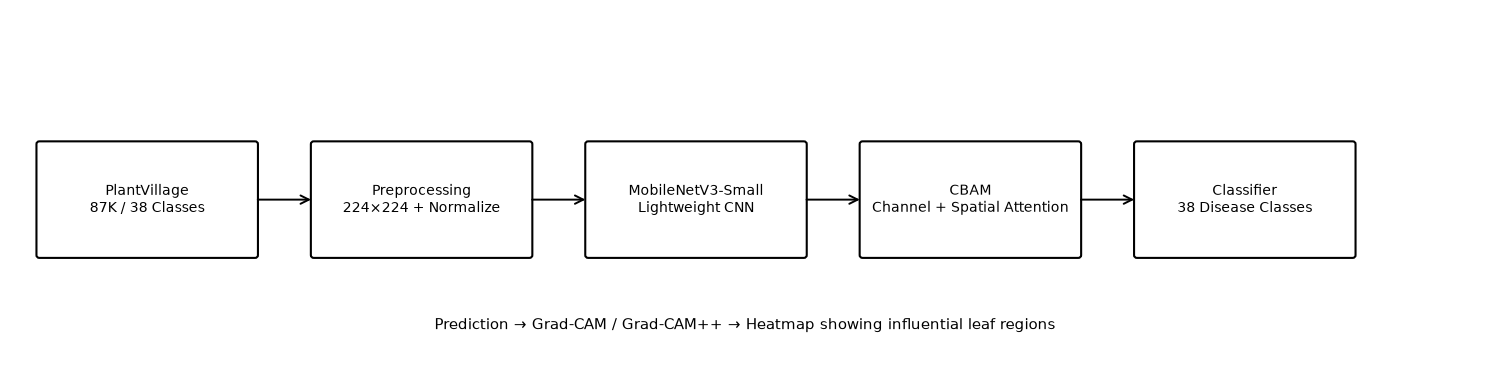

In [28]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def pipeline_diagram(path):
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 4)
    ax.axis("off")

    boxes = [
        (0.3, "PlantVillage\n87K / 38 Classes"),
        (3.1, "Preprocessing\n224×224 + Normalize"),
        (5.9, "MobileNetV3-Small\nLightweight CNN"),
        (8.7, "CBAM\nChannel + Spatial Attention"),
        (11.5, "Classifier\n38 Disease Classes"),
    ]
    for i, (x, label) in enumerate(boxes):
        rect = FancyBboxPatch((x, 1.35), 2.2, 1.2,
                              boxstyle="round,pad=0.03",
                              linewidth=1.5, fill=False)
        ax.add_patch(rect)
        ax.text(x+1.1, 1.95, label, ha="center", va="center", fontsize=10)
        if i < len(boxes)-1:
            ax.add_patch(FancyArrowPatch(
                (x+2.2, 1.95), (boxes[i+1][0], 1.95),
                arrowstyle="->", mutation_scale=15, linewidth=1.4
            ))

    ax.text(7.5, 0.55,
            "Prediction → Grad-CAM / Grad-CAM++ → Heatmap showing influential leaf regions",
            ha="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

pipeline_diagram(FIG_ROOT / "03_leafguard_system_pipeline.png")


## 11. Model Complexity: Parameters and FLOPs

In [29]:
def model_complexity(model):
    model.eval()
    x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    with torch.no_grad():
        flops, params = profile(model, inputs=(x,), verbose=False)
    return int(params), int(flops)

baseline_params, baseline_flops = model_complexity(baseline)
cbam_params, cbam_flops = model_complexity(cbam_model)

complexity_df = pd.DataFrame({
    "Model": ["MobileNetV3-Small", "MobileNetV3-Small + CBAM"],
    "Parameters": [baseline_params, cbam_params],
    "FLOPs": [baseline_flops, cbam_flops]
})
complexity_df["Parameters_M"] = complexity_df["Parameters"] / 1e6
complexity_df["FLOPs_M"] = complexity_df["FLOPs"] / 1e6
complexity_df


,Model,Parameters,FLOPs,Parameters_M,FLOPs_M
0,MobileNetV3-Small,1556806,61492856,1.556806,61.492856
1,MobileNetV3-Small + CBAM,1562524,62218398,1.562524,62.218398


## 12. Training Utilities

In [30]:
def evaluate_loader(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            probs = torch.softmax(logits, dim=1)
            total_loss += loss.item() * y.size(0)

            preds = logits.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.append(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.concatenate(y_prob, axis=0)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    top5 = (np.argsort(y_prob, axis=1)[:, -5:] == y_true[:, None]).any(axis=1).mean()
    return total_loss / len(loader.dataset), acc, macro_f1, top5, y_true, y_pred, y_prob

    def evaluate_loader(model, loader):

      def train_model(model, model_name, train_loader, val_loader):
      # """Train one model and return the best checkpoint plus epoch history."""
        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS
        )

        best_f1 = -float("inf")
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        rows = []

        ckpt_path = MODEL_ROOT / f"{model_name}_best.pth"

        for epoch in range(1, EPOCHS + 1):

            # -------------------------
            # Training
            # -------------------------
            model.train()

            running_loss = 0.0
            seen = 0

            pbar = tqdm(
                train_loader,
                desc=f"{model_name} | Epoch {epoch}/{EPOCHS}"
            )

            for x, y in pbar:

                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                logits = model(x)
                loss = criterion(logits, y)

                loss.backward()
                optimizer.step()

                batch_size = y.size(0)

                running_loss += loss.item() * batch_size
                seen += batch_size

                pbar.set_postfix(
                    loss=f"{loss.item():.4f}"
                )

            scheduler.step()

            train_loss = running_loss / max(seen, 1)

            # -------------------------
            # Validation
            # -------------------------
            (
                val_loss,
                val_acc,
                val_f1,
                val_top5,
                _,
                _,
                _
            ) = evaluate_loader(
                model,
                val_loader
            )

            row = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": val_f1,
                "val_top5_accuracy": val_top5,
                "lr": optimizer.param_groups[0]["lr"],
            }

            rows.append(row)

            print(
                f"Epoch {epoch:02d}: "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f} | "
                f"val_macro_f1={val_f1:.4f}"
            )

            # -------------------------
            # Save best model
            # -------------------------
            if val_f1 > best_f1:

                best_f1 = val_f1
                best_state = copy.deepcopy(
                    model.state_dict()
                )

                torch.save(
                    best_state,
                    ckpt_path
                )

                patience_counter = 0

                print(
                    f"  ✓ New best Macro-F1: {best_f1:.4f}"
                )

            else:

                patience_counter += 1

                if patience_counter >= PATIENCE:

                    print(
                        f"  Early stopping after "
                        f"{epoch} epochs."
                    )

                    break

        # Restore best model
        model.load_state_dict(best_state)

        history = pd.DataFrame(rows)

        print(
            f"Best validation Macro-F1 "
            f"({model_name}): {best_f1:.4f}"
        )

        print(
            f"Best checkpoint: {ckpt_path}"
        )

        return model, history


In [31]:
# ============================================================
# 12B — TRAIN MODEL
# Run this cell BEFORE Section 13
# ============================================================

def train_model(model, model_name, train_loader, val_loader):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_f1 = -float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = []

    ckpt_path = MODEL_ROOT / f"{model_name}_best.pth"

    for epoch in range(1, EPOCHS + 1):

        print("\n" + "=" * 60)
        print(f"{model_name.upper()} — EPOCH {epoch}/{EPOCHS}")
        print("=" * 60)

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.train()

        running_loss = 0.0
        total_samples = 0

        progress = tqdm(
            train_loader,
            desc=f"Training {model_name}"
        )

        for images, labels in progress:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

        train_loss = (
            running_loss /
            max(total_samples, 1)
        )

        # -----------------------------
        # VALIDATION
        # -----------------------------
        (
            val_loss,
            val_accuracy,
            val_f1,
            val_top5,
            _,
            _,
            _
        ) = evaluate_loader(
            model,
            val_loader
        )

        scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_f1,
            "val_top5_accuracy": val_top5,
            "learning_rate":
                optimizer.param_groups[0]["lr"]
        })

        print(
            f"Train Loss       : {train_loss:.4f}"
        )

        print(
            f"Validation Loss  : {val_loss:.4f}"
        )

        print(
            f"Validation Acc   : {val_accuracy * 100:.2f}%"
        )

        print(
            f"Validation F1    : {val_f1 * 100:.2f}%"
        )

        print(
            f"Validation Top-5 : {val_top5 * 100:.2f}%"
        )

        # -----------------------------
        # BEST MODEL
        # -----------------------------
        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_state,
                ckpt_path
            )

            patience_counter = 0

            print(
                "✓ New best model saved"
            )

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{PATIENCE})"
            )

        # -----------------------------
        # EARLY STOPPING
        # -----------------------------
        if patience_counter >= PATIENCE:

            print(
                "\nEarly stopping triggered."
            )

            break

    # -----------------------------
    # RESTORE BEST MODEL
    # -----------------------------
    model.load_state_dict(
        best_state
    )

    history = pd.DataFrame(
        history
    )

    history.to_csv(
        REPORT_ROOT /
        f"{model_name}_training_history.csv",
        index=False
    )

    print("\n" + "=" * 60)
    print(f"{model_name.upper()} TRAINING COMPLETE")
    print(
        f"Best Macro-F1: "
        f"{best_f1 * 100:.2f}%"
    )
    print(
        f"Checkpoint: {ckpt_path}"
    )
    print("=" * 60)

    return model, history


print("✅ train_model() successfully defined.")

✅ train_model() successfully defined.


## 13. Train Baseline and CBAM Models

This is the main compute-heavy section. Both models are trained independently.


In [32]:
# Train baseline
baseline, baseline_history = train_model(
    baseline, "baseline", train_loader, val_loader
)

# Train CBAM
cbam_model, cbam_history = train_model(
    cbam_model, "cbam", train_loader, val_loader
)

baseline_history.to_csv(REPORT_ROOT / "baseline_training_history.csv", index=False)
cbam_history.to_csv(REPORT_ROOT / "cbam_training_history.csv", index=False)

print("Training complete.")



BASELINE — EPOCH 1/20


Training baseline: 100%|██████████| 1758/1758 [04:06<00:00,  7.14it/s, loss=0.6355]


Train Loss       : 0.2230
Validation Loss  : 0.0965
Validation Acc   : 96.88%
Validation F1    : 96.86%
Validation Top-5 : 99.90%
✓ New best model saved

BASELINE — EPOCH 2/20


Training baseline: 100%|██████████| 1758/1758 [04:18<00:00,  6.79it/s, loss=0.0024]


Train Loss       : 0.0525
Validation Loss  : 0.0523
Validation Acc   : 98.28%
Validation F1    : 98.27%
Validation Top-5 : 99.96%
✓ New best model saved

BASELINE — EPOCH 3/20


...

Train Loss       : 0.0031
Validation Loss  : 0.0113
Validation Acc   : 99.72%
Validation F1    : 99.71%
Validation Top-5 : 99.99%
No improvement (1/5)

CBAM — EPOCH 19/20


Training cbam: 100%|██████████| 1758/1758 [03:58<00:00,  7.36it/s, loss=0.0002]


Train Loss       : 0.0029
Validation Loss  : 0.0098
Validation Acc   : 99.74%
Validation F1    : 99.74%
Validation Top-5 : 99.99%
✓ New best model saved

CBAM — EPOCH 20/20


Training cbam: 100%|██████████| 1758/1758 [04:04<00:00,  7.20it/s, loss=0.0001]


Train Loss       : 0.0022
Validation Loss  : 0.0098
Validation Acc   : 99.74%
Validation F1    : 99.74%
Validation Top-5 : 99.99%
No improvement (1/5)

CBAM TRAINING COMPLETE
Best Macro-F1: 99.74%
Checkpoint: /home/gopal/Downloads/capstone/runs/models/cbam_best.pth
Training complete.


## 14. Training Curves

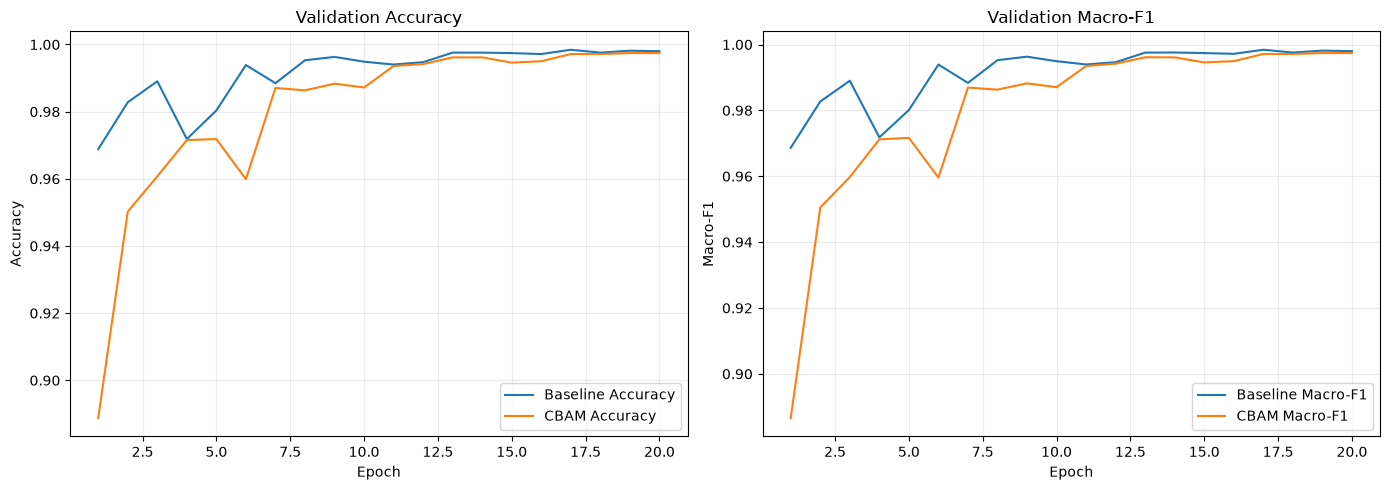

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history["epoch"], baseline_history["val_accuracy"], label="Baseline Accuracy")
axes[0].plot(cbam_history["epoch"], cbam_history["val_accuracy"], label="CBAM Accuracy")
axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(baseline_history["epoch"], baseline_history["val_macro_f1"], label="Baseline Macro-F1")
axes[1].plot(cbam_history["epoch"], cbam_history["val_macro_f1"], label="CBAM Macro-F1")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_ROOT / "04_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 15. Final Test Evaluation

The final test set is evaluated only after model selection. This section calculates Accuracy, Macro-F1, Macro-Precision, Macro-Recall and the full per-class classification report.


In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score

def test_model(model, name):
    loss, acc, macro_f1, top5, y_true, y_pred, y_prob = evaluate_loader(model, test_loader)

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(REPORT_ROOT / f"{name}_classification_report.csv")

    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    try:
        macro_roc_auc = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
        macro_pr_auc = average_precision_score(y_bin, y_prob, average="macro")
    except Exception as e:
        macro_roc_auc, macro_pr_auc = np.nan, np.nan

    metrics = {
        "Model": name,
        "Accuracy": acc,
        "Top-5 Accuracy": top5,
        "Macro-F1": macro_f1,
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-ROC-AUC": macro_roc_auc,
        "Macro-PR-AUC": macro_pr_auc,
        "Test Loss": loss
    }
    return metrics, y_true, y_pred, y_prob, report_df


In [39]:
# Final test evaluation for both models

baseline_metrics, yb_true, yb_pred, yb_prob, baseline_report = test_model(
    baseline,
    "baseline"
)

cbam_metrics, yc_true, yc_pred, yc_prob, cbam_report = test_model(
    cbam_model,
    "cbam"
)

print("Baseline metrics:")
print(baseline_metrics)

print("\nCBAM metrics:")
print(cbam_metrics)

Baseline metrics:
{'Model': 'baseline', 'Accuracy': 0.997724039829303, 'Top-5 Accuracy': np.float64(1.0), 'Macro-F1': 0.997702035688115, 'Macro-Precision': 0.9976659361503483, 'Macro-Recall': 0.9977543870021395, 'Macro-ROC-AUC': 0.9999983818215382, 'Macro-PR-AUC': 0.9999418244347256, 'Test Loss': 0.0072031640778712725}

CBAM metrics:
{'Model': 'cbam', 'Accuracy': 0.9971550497866287, 'Top-5 Accuracy': np.float64(1.0), 'Macro-F1': 0.997118602272413, 'Macro-Precision': 0.9971337998684671, 'Macro-Recall': 0.9971400929366074, 'Macro-ROC-AUC': 0.9999984273238773, 'Macro-PR-AUC': 0.9999424699801117, 'Test Loss': 0.008370333155042532}


## 16. Confusion Matrices

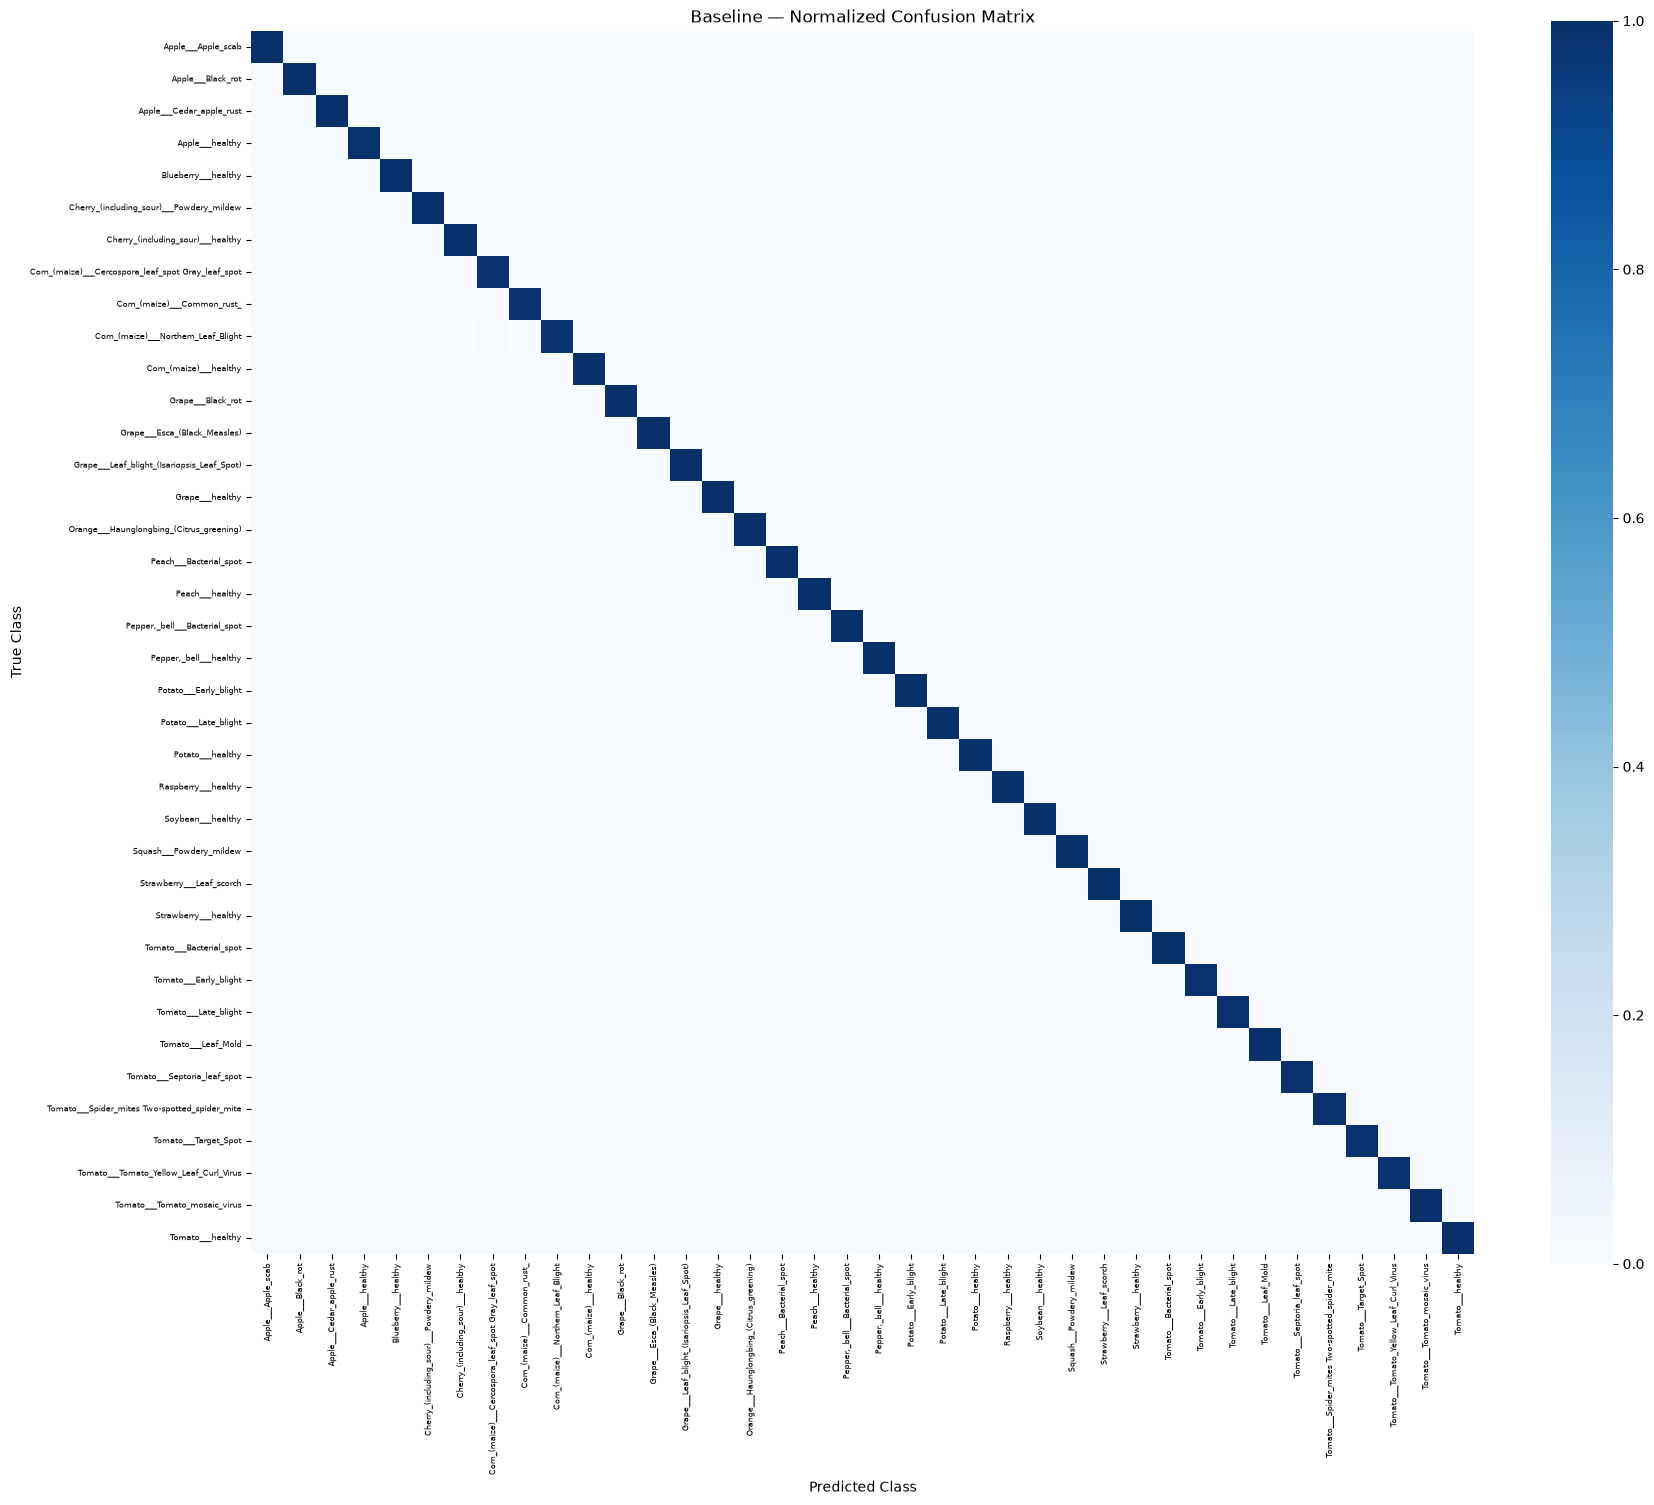

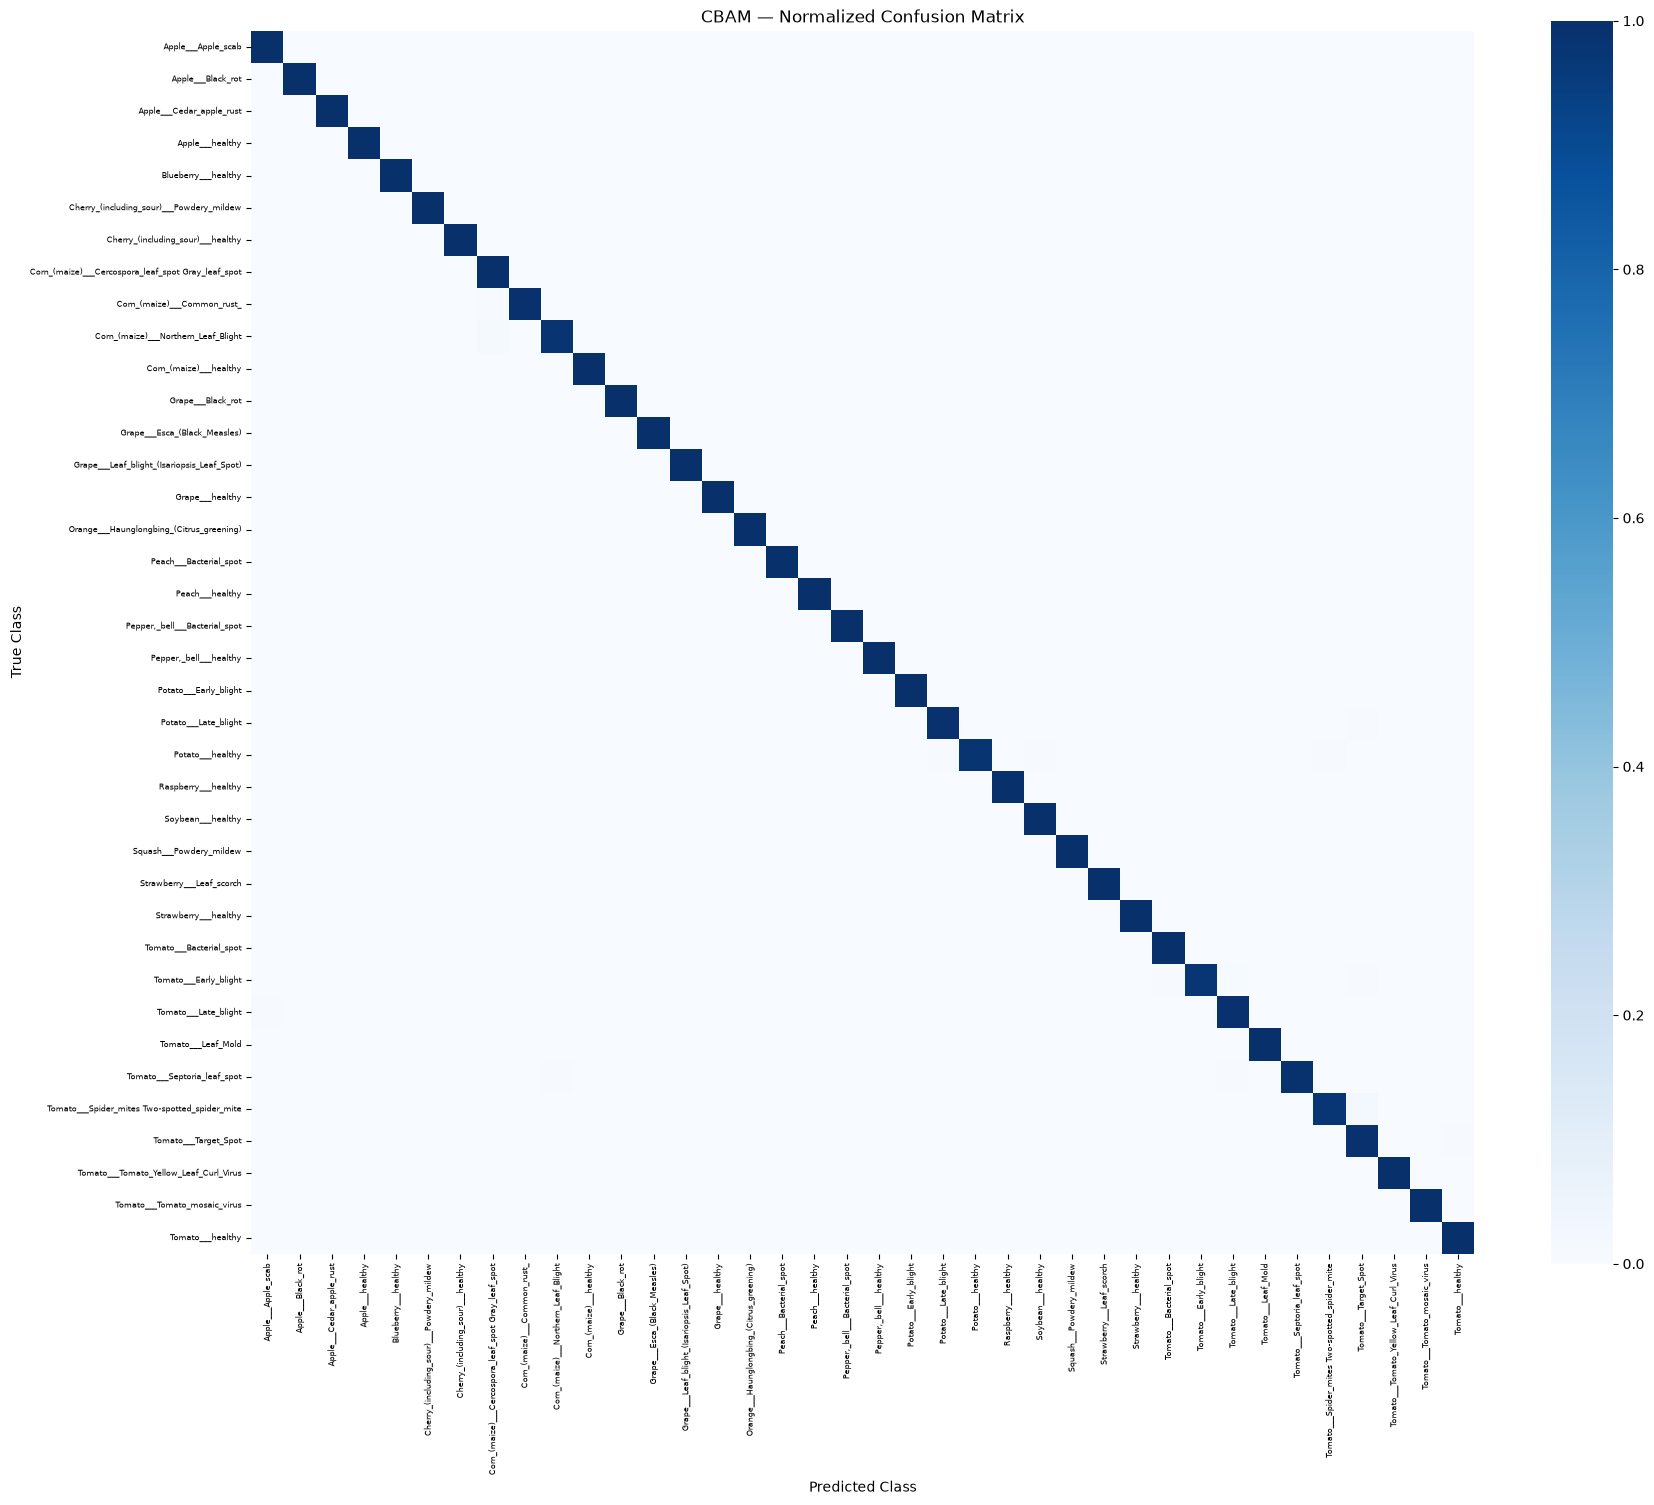

In [40]:
def plot_confusion(y_true, y_pred, title, filename, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(18, 15))
    sns.heatmap(
        cm, cmap="Blues", square=True,
        xticklabels=class_names, yticklabels=class_names,
        cbar=True
    )
    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0, fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_ROOT / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_confusion(yb_true, yb_pred, "Baseline — Normalized Confusion Matrix",
               "05_confusion_baseline.png")
plot_confusion(yc_true, yc_pred, "CBAM — Normalized Confusion Matrix",
               "06_confusion_cbam.png")


## 16A. Multi-Class ROC-AUC and Precision–Recall Curves

These plots are useful for the appendix/report and provide additional evidence beyond accuracy and Macro-F1.


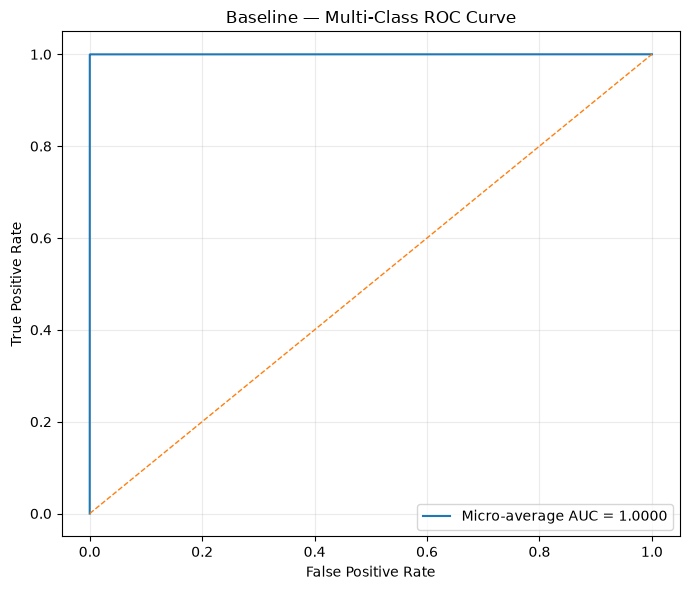

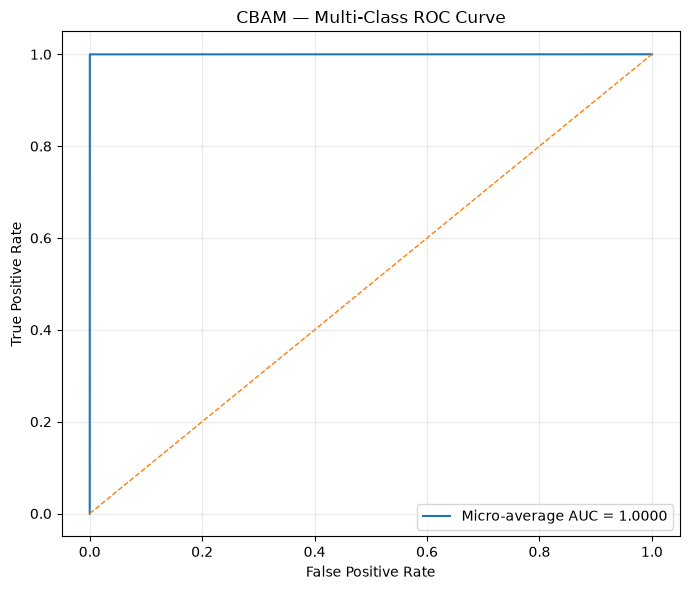

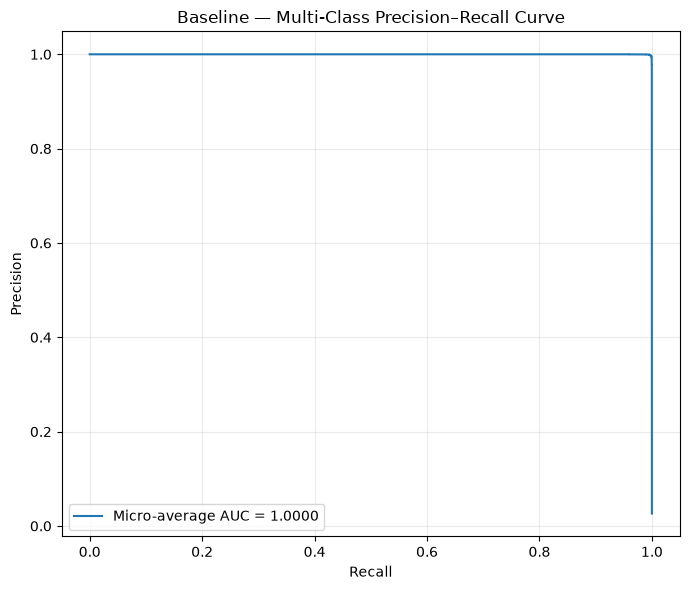

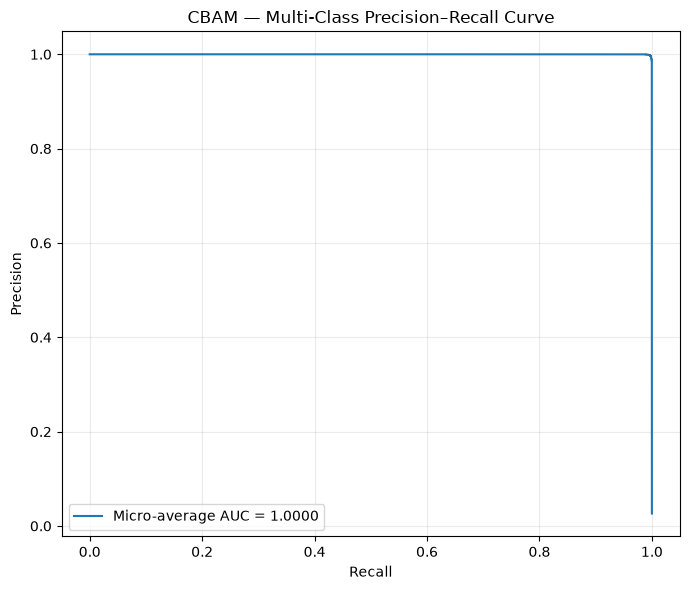

In [41]:

from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

def plot_micro_roc(y_true, y_prob, name, filename):
    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
    score = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"Micro-average AUC = {score:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} — Multi-Class ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_ROOT / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_micro_roc(yb_true, yb_prob, "Baseline", "10_roc_baseline.png")
plot_micro_roc(yc_true, yc_prob, "CBAM", "11_roc_cbam.png")

def plot_micro_pr(y_true, y_prob, name, filename):
    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_prob.ravel())
    score = auc(recall, precision)
    plt.figure(figsize=(7,6))
    plt.plot(recall, precision, label=f"Micro-average AUC = {score:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} — Multi-Class Precision–Recall Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_ROOT / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_micro_pr(yb_true, yb_prob, "Baseline", "12_pr_baseline.png")
plot_micro_pr(yc_true, yc_prob, "CBAM", "13_pr_cbam.png")


## 17. Per-Class F1 Comparison

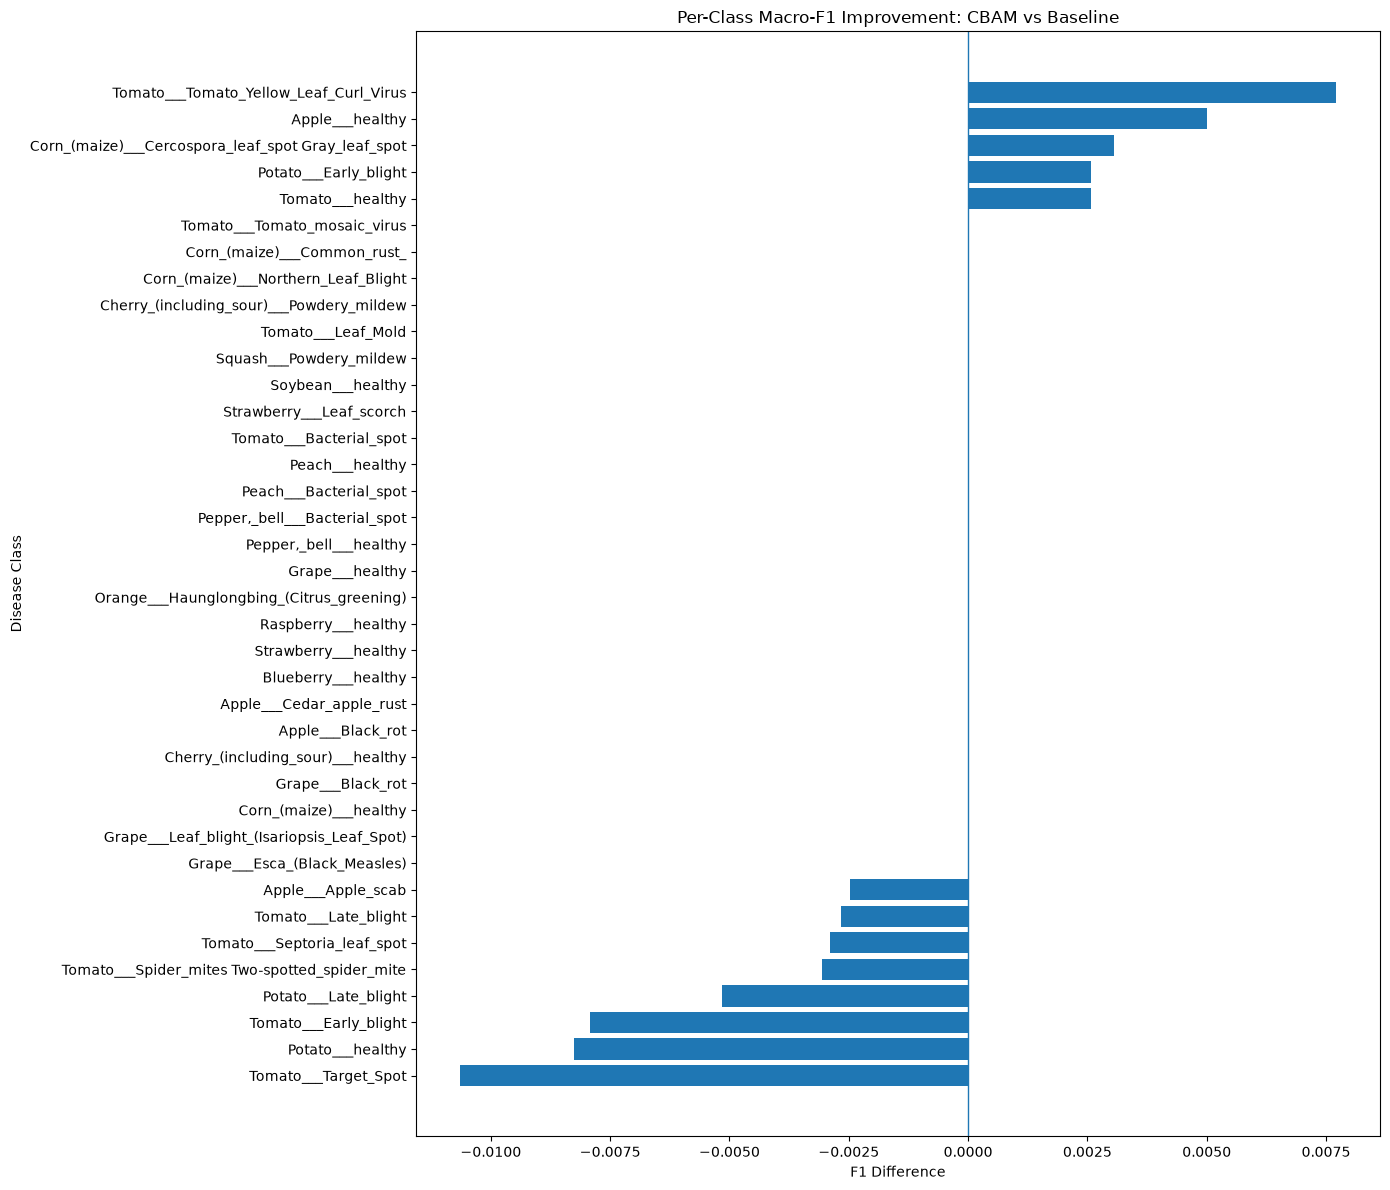

In [42]:
per_class = pd.DataFrame({
    "Class": class_names,
    "Baseline_F1": baseline_report.loc[class_names, "f1-score"].values,
    "CBAM_F1": cbam_report.loc[class_names, "f1-score"].values
})
per_class["Improvement"] = per_class["CBAM_F1"] - per_class["Baseline_F1"]

plot_df = per_class.sort_values("Improvement")
plt.figure(figsize=(14, 12))
plt.barh(plot_df["Class"], plot_df["Improvement"])
plt.axvline(0, linewidth=1)
plt.title("Per-Class Macro-F1 Improvement: CBAM vs Baseline")
plt.xlabel("F1 Difference")
plt.ylabel("Disease Class")
plt.tight_layout()
plt.savefig(FIG_ROOT / "07_per_class_f1_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

per_class.to_csv(REPORT_ROOT / "per_class_f1_comparison.csv", index=False)


## 18. Model Size and Inference Speed

The paper specification requires model size, FLOPs, parameters and inference speed. Size is measured from the saved checkpoint files. FPS is measured separately on CPU and, when available, GPU.

**For reproducibility, report the hardware used for the benchmark.**


In [43]:
def checkpoint_size_mb(path):
    return os.path.getsize(path) / 1e6

def benchmark_fps(model, device, loader, warmup=5, iterations=20):
    model = model.to(device).eval()
    batch = next(iter(loader))[0].to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(batch)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        total_images = 0
        for _ in range(iterations):
            _ = model(batch)
            total_images += batch.size(0)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    return total_images / elapsed

baseline_path = MODEL_ROOT / "baseline_best.pth"
cbam_path = MODEL_ROOT / "cbam_best.pth"

benchmark_devices = [torch.device("cpu")]
if torch.cuda.is_available():
    benchmark_devices.append(torch.device("cuda"))

bench_rows = []
for dev in benchmark_devices:
    for name, model, path, params, flops in [
        ("Baseline", baseline, baseline_path, baseline_params, baseline_flops),
        ("CBAM", cbam_model, cbam_path, cbam_params, cbam_flops)
    ]:
        fps = benchmark_fps(model, dev, test_loader)
        bench_rows.append({
            "Model": name,
            "Device": str(dev),
            "FPS": fps,
            "Latency_ms_per_image": 1000 / fps,
            "Parameters": params,
            "FLOPs": flops,
            "Model_Size_MB": checkpoint_size_mb(path)
        })

efficiency_df = pd.DataFrame(bench_rows)
efficiency_df.to_csv(REPORT_ROOT / "efficiency_benchmark.csv", index=False)
efficiency_df


,Model,Device,FPS,Latency_ms_per_image,Parameters,FLOPs,Model_Size_MB
0,Baseline,cpu,233.159496,4.288910,1556806,61492856,6.413771
1,CBAM,cpu,247.652749,4.037912,1562524,62218398,6.485835
2,Baseline,cuda,2949.176777,0.339078,1556806,61492856,6.413771
3,CBAM,cuda,2134.011003,0.468601,1562524,62218398,6.485835


## 19. Final Paper Comparison Table

This creates the compact table that can be copied directly into the IEEE paper/report.


In [44]:
cpu_df = efficiency_df[efficiency_df["Device"] == "cpu"].copy()

final_table = pd.DataFrame({
    "Metric": [
        "Accuracy (%)", "Macro-F1 (%)", "Macro-Precision (%)", "Macro-Recall (%)",
        "Parameters", "FLOPs (M)", "Model Size (MB)", "CPU FPS", "CPU Latency (ms)"
    ],
    "Baseline MobileNetV3-Small": [
        baseline_metrics["Accuracy"]*100,
        baseline_metrics["Macro-F1"]*100,
        baseline_metrics["Macro-Precision"]*100,
        baseline_metrics["Macro-Recall"]*100,
        baseline_params,
        baseline_flops/1e6,
        float(cpu_df.loc[cpu_df.Model=="Baseline", "Model_Size_MB"].iloc[0]),
        float(cpu_df.loc[cpu_df.Model=="Baseline", "FPS"].iloc[0]),
        float(cpu_df.loc[cpu_df.Model=="Baseline", "Latency_ms_per_image"].iloc[0])
    ],
    "MobileNetV3-Small + CBAM": [
        cbam_metrics["Accuracy"]*100,
        cbam_metrics["Macro-F1"]*100,
        cbam_metrics["Macro-Precision"]*100,
        cbam_metrics["Macro-Recall"]*100,
        cbam_params,
        cbam_flops/1e6,
        float(cpu_df.loc[cpu_df.Model=="CBAM", "Model_Size_MB"].iloc[0]),
        float(cpu_df.loc[cpu_df.Model=="CBAM", "FPS"].iloc[0]),
        float(cpu_df.loc[cpu_df.Model=="CBAM", "Latency_ms_per_image"].iloc[0])
    ]
})

final_table.to_csv(REPORT_ROOT / "FINAL_PAPER_TABLE.csv", index=False)
final_table


,Metric,Baseline MobileNetV3-Small,MobileNetV3-Small + CBAM
0,Accuracy (%),9.977240e+01,9.971550e+01
1,Macro-F1 (%),9.977020e+01,9.971186e+01
2,Macro-Precision (%),9.976659e+01,9.971338e+01
3,Macro-Recall (%),9.977544e+01,9.971401e+01
4,Parameters,1.556806e+06,1.562524e+06
5,FLOPs (M),6.149286e+01,6.221840e+01
6,Model Size (MB),6.413771e+00,6.485835e+00
7,CPU FPS,2.331595e+02,2.476527e+02
8,CPU Latency (ms),4.288910e+00,4.037912e+00


## 20. Percentage Gain / Cost Analysis

This section calculates the exact experimental effect of CBAM instead of using the project's proposed 5–8% improvement as an assumed result.


In [45]:
def pct_change(new, old):
    return ((new - old) / old) * 100 if old != 0 else np.nan

gain_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1", "Parameters", "FLOPs", "Model Size", "CPU FPS"],
    "Baseline": [
        baseline_metrics["Accuracy"], baseline_metrics["Macro-F1"],
        baseline_params, baseline_flops,
        cpu_df.loc[cpu_df.Model=="Baseline", "Model_Size_MB"].iloc[0],
        cpu_df.loc[cpu_df.Model=="Baseline", "FPS"].iloc[0]
    ],
    "CBAM": [
        cbam_metrics["Accuracy"], cbam_metrics["Macro-F1"],
        cbam_params, cbam_flops,
        cpu_df.loc[cpu_df.Model=="CBAM", "Model_Size_MB"].iloc[0],
        cpu_df.loc[cpu_df.Model=="CBAM", "FPS"].iloc[0]
    ]
})
gain_df["Change_%"] = [
    pct_change(gain_df.loc[i, "CBAM"], gain_df.loc[i, "Baseline"])
    for i in range(len(gain_df))
]
gain_df.to_csv(REPORT_ROOT / "cbam_gain_analysis.csv", index=False)
gain_df


,Metric,Baseline,CBAM,Change_%
0,Accuracy,9.977240e-01,9.971550e-01,-0.057029
1,Macro-F1,9.977020e-01,9.971186e-01,-0.058478
2,Parameters,1.556806e+06,1.562524e+06,0.367290
3,FLOPs,6.149286e+07,6.221840e+07,1.179880
4,Model Size,6.413771e+00,6.485835e+00,1.123582
5,CPU FPS,2.331595e+02,2.476527e+02,6.216025


## 21. Grad-CAM / Grad-CAM++ Explainability

Grad-CAM is used to visualize the regions that contribute most strongly to a prediction. The notebook automatically selects representative test images and produces overlays for the CBAM model.

The visualizations should be described as **model attention/explanation evidence**, not proof that the highlighted region is medically or agronomically diagnostic.


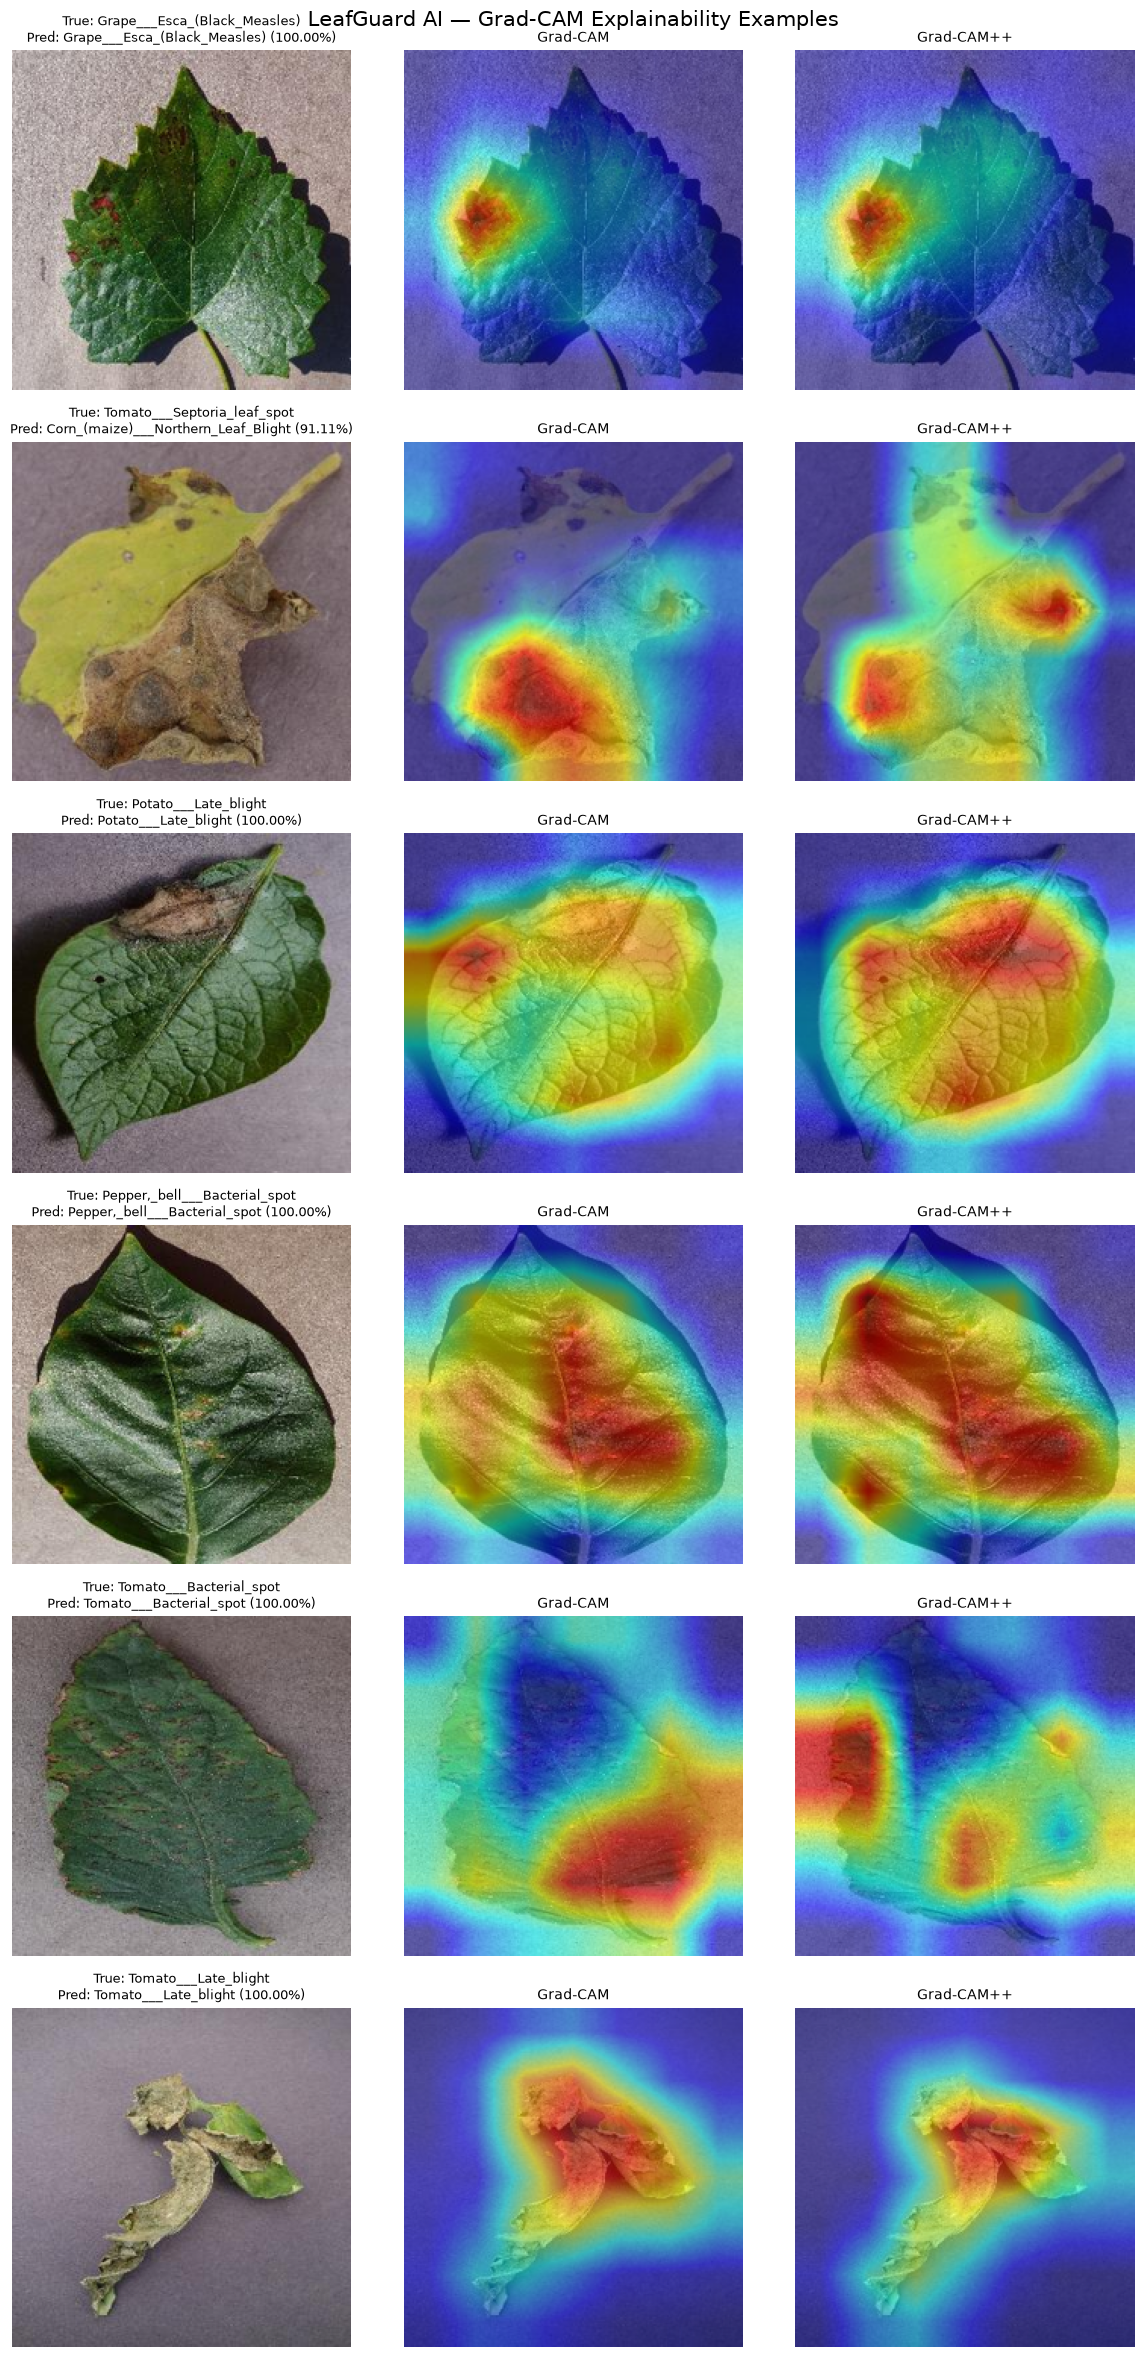

In [46]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Find a target convolutional layer.
def get_last_conv_layer(model):
    convs = []
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            convs.append(module)
    if not convs:
        raise RuntimeError("No Conv2d layer found.")
    return convs[-1]

target_layer = get_last_conv_layer(cbam_model)

# Build raw test image lookup
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t.cpu() * std + mean).clamp(0,1)

def make_gradcam_examples(n=6):
    rows = []
    used_classes = set()

    for _, row in test_df.sample(frac=1, random_state=SEED).iterrows():
        cls = int(row["label"])
        if cls in used_classes:
            continue
        used_classes.add(cls)
        rows.append(row)
        if len(rows) >= n:
            break

    fig, axes = plt.subplots(len(rows), 3, figsize=(12, 4*len(rows)))
    if len(rows) == 1:
        axes = np.array([axes])

    cbam_model.eval()

    for i, row in enumerate(rows):
        pil = Image.open(row["path"]).convert("RGB")
        inp = eval_tf(pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = cbam_model(inp)
            pred = int(logits.argmax(1).item())
            conf = float(torch.softmax(logits, 1).max().item())

        rgb = np.array(pil.resize((IMAGE_SIZE, IMAGE_SIZE))).astype(np.float32) / 255.0

        for j, (method_name, cam_cls) in enumerate([
            ("Original", None),
            ("Grad-CAM", GradCAM),
            ("Grad-CAM++", GradCAMPlusPlus)
        ]):
            if cam_cls is None:
                axes[i,j].imshow(rgb)
                axes[i,j].set_title(
                    f"True: {class_names[int(row['label'])]}\n"
                    f"Pred: {class_names[pred]} ({conf:.2%})", fontsize=9
                )
            else:
                cam = cam_cls(model=cbam_model, target_layers=[target_layer])
                targets = [ClassifierOutputTarget(pred)]
                grayscale = cam(input_tensor=inp, targets=targets)[0]
                overlay = show_cam_on_image(rgb, grayscale, use_rgb=True)
                axes[i,j].imshow(overlay)
                axes[i,j].set_title(method_name, fontsize=10)

            axes[i,j].axis("off")

    plt.suptitle("LeafGuard AI — Grad-CAM Explainability Examples", fontsize=15)
    plt.tight_layout()
    plt.savefig(FIG_ROOT / "08_gradcam_examples.png", dpi=300, bbox_inches="tight")
    plt.show()

make_gradcam_examples()


## 22. Accuracy–Efficiency Trade-off Figure

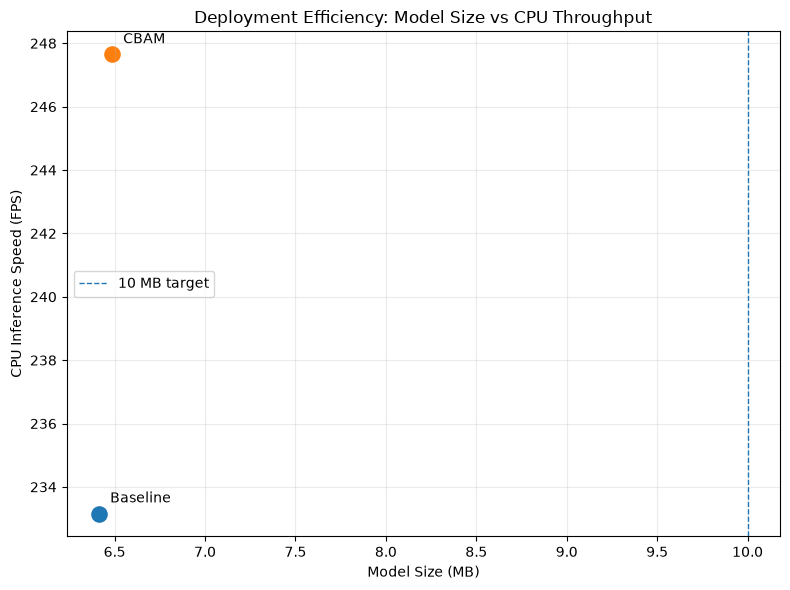

In [47]:
# Use CPU benchmark because the project specifically targets lightweight deployment.
plot_eff = cpu_df.copy()

plt.figure(figsize=(8, 6))
for _, r in plot_eff.iterrows():
    plt.scatter(r["Model_Size_MB"], r["FPS"], s=120)
    plt.annotate(r["Model"], (r["Model_Size_MB"], r["FPS"]),
                 xytext=(8, 8), textcoords="offset points")

plt.axvline(10, linestyle="--", linewidth=1, label="10 MB target")
plt.xlabel("Model Size (MB)")
plt.ylabel("CPU Inference Speed (FPS)")
plt.title("Deployment Efficiency: Model Size vs CPU Throughput")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_ROOT / "09_efficiency_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()


## 23. Paper-Ready Summary Statistics

This prints a concise result block that can be used when writing the Results section.


In [48]:
base_acc = baseline_metrics["Accuracy"] * 100
cbam_acc = cbam_metrics["Accuracy"] * 100
base_f1 = baseline_metrics["Macro-F1"] * 100
cbam_f1 = cbam_metrics["Macro-F1"] * 100

cpu_base = float(cpu_df.loc[cpu_df.Model=="Baseline", "FPS"].iloc[0])
cpu_cbam = float(cpu_df.loc[cpu_df.Model=="CBAM", "FPS"].iloc[0])

print("="*70)
print("LEAFGUARD AI — PAPER-READY RESULT SUMMARY")
print("="*70)
print(f"Dataset/classes: {len(all_df):,} labeled images / {len(class_names)} classes")
print(f"Baseline accuracy: {base_acc:.2f}%")
print(f"CBAM accuracy:     {cbam_acc:.2f}%")
print(f"Accuracy change:   {cbam_acc-base_acc:+.2f} percentage points")
print(f"Baseline Macro-F1: {base_f1:.2f}%")
print(f"CBAM Macro-F1:     {cbam_f1:.2f}%")
print(f"Macro-F1 change:   {cbam_f1-base_f1:+.2f} percentage points")
print(f"Baseline Top-5:    {baseline_metrics['Top-5 Accuracy']*100:.2f}%")
print(f"CBAM Top-5:        {cbam_metrics['Top-5 Accuracy']*100:.2f}%")
print(f"Baseline ROC-AUC:  {baseline_metrics['Macro-ROC-AUC']:.4f}")
print(f"CBAM ROC-AUC:      {cbam_metrics['Macro-ROC-AUC']:.4f}")
print(f"Baseline PR-AUC:   {baseline_metrics['Macro-PR-AUC']:.4f}")
print(f"CBAM PR-AUC:       {cbam_metrics['Macro-PR-AUC']:.4f}")
print(f"Baseline params:   {baseline_params:,}")
print(f"CBAM params:       {cbam_params:,}")
print(f"Baseline FLOPs:    {baseline_flops/1e6:.2f} M")
print(f"CBAM FLOPs:        {cbam_flops/1e6:.2f} M")
print(f"Baseline size:     {float(cpu_df.loc[cpu_df.Model=='Baseline','Model_Size_MB'].iloc[0]):.2f} MB")
print(f"CBAM size:         {float(cpu_df.loc[cpu_df.Model=='CBAM','Model_Size_MB'].iloc[0]):.2f} MB")
print(f"Baseline CPU FPS:  {cpu_base:.2f}")
print(f"CBAM CPU FPS:      {cpu_cbam:.2f}")
print(f"CPU FPS change:    {cpu_cbam-cpu_base:+.2f}")
print("="*70)


LEAFGUARD AI — PAPER-READY RESULT SUMMARY
Dataset/classes: 70,295 labeled images / 38 classes
Baseline accuracy: 99.77%
CBAM accuracy:     99.72%
Accuracy change:   -0.06 percentage points
Baseline Macro-F1: 99.77%
CBAM Macro-F1:     99.71%
Macro-F1 change:   -0.06 percentage points
Baseline Top-5:    100.00%
CBAM Top-5:        100.00%
Baseline ROC-AUC:  1.0000
CBAM ROC-AUC:      1.0000
Baseline PR-AUC:   0.9999
CBAM PR-AUC:       0.9999
Baseline params:   1,556,806
CBAM params:       1,562,524
Baseline FLOPs:    61.49 M
CBAM FLOPs:        62.22 M
Baseline size:     6.41 MB
CBAM size:         6.49 MB
Baseline CPU FPS:  233.16
CBAM CPU FPS:      247.65
CPU FPS change:    +14.49


## 24. Export Complete Research Package

The final cell saves:
- CSV result tables
- classification reports
- training histories
- confusion matrices
- Grad-CAM figures
- efficiency figures
- model checkpoints
- split manifests
- a JSON summary
- a Markdown paper-results table

The complete folder is zipped so it can be downloaded from Colab.


In [49]:
summary_json = {
    "project": "LeafGuard AI",
    "seed": SEED,
    "device": str(DEVICE),
    "dataset": KAGGLE_DATASET,
    "num_classes": len(class_names),
    "num_images_total": int(len(all_df)),
    "split_sizes": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df))
    },
    "baseline": {
        "accuracy": float(baseline_metrics["Accuracy"]),
        "macro_f1": float(baseline_metrics["Macro-F1"]),
        "macro_precision": float(baseline_metrics["Macro-Precision"]),
        "macro_recall": float(baseline_metrics["Macro-Recall"]),
        "parameters": int(baseline_params),
        "flops": int(baseline_flops)
    },
    "cbam": {
        "accuracy": float(cbam_metrics["Accuracy"]),
        "macro_f1": float(cbam_metrics["Macro-F1"]),
        "macro_precision": float(cbam_metrics["Macro-Precision"]),
        "macro_recall": float(cbam_metrics["Macro-Recall"]),
        "parameters": int(cbam_params),
        "flops": int(cbam_flops)
    },
    "hypothesis": "CBAM may improve fine-grained disease recognition while remaining below a 10 MB deployment target.",
    "note": "Measured results, not assumed 5-8% gains, should be reported in the paper."
}

with open(REPORT_ROOT / "experiment_summary.json", "w") as f:
    json.dump(summary_json, f, indent=2)

paper_md = "# LeafGuard AI — Experimental Results\n\n"
paper_md += final_table.to_markdown(index=False, floatfmt=".2f")
paper_md += "\n\n## CBAM Gain Analysis\n\n"
paper_md += gain_df.to_markdown(index=False, floatfmt=".4f")
paper_md += "\n"

with open(REPORT_ROOT / "paper_results_tables.md", "w") as f:
    f.write(paper_md)

zip_path = shutil.make_archive(
    str(ROOT / "LeafGuard_AI_Research_Results"),
    "zip",
    root_dir=RUN_ROOT
)

print("Research package created:", zip_path)
print("Figures:", FIG_ROOT)
print("Reports:", REPORT_ROOT)


Research package created: /home/gopal/Downloads/capstone/LeafGuard_AI_Research_Results.zip
Figures: /home/gopal/Downloads/capstone/runs/figures
Reports: /home/gopal/Downloads/capstone/runs/reports
